In [2]:
import scipy.io

In [3]:
import scipy.io

battery = scipy.io.loadmat(
    "../data/NASA/5. Battery Data Set/1. BatteryAgingARC-FY08Q4/B0005.mat"
)

In [4]:
battery.keys()

dict_keys(['__header__', '__version__', '__globals__', 'B0005'])

In [5]:
#MATLAB 구조체라서 1,1, 원래는 행열
battery["B0005"].shape

(1, 1)

In [6]:
#numpy 배열 형태
type(battery["B0005"])

numpy.ndarray

In [7]:
# 배열 안에 데이터 확인
battery["B0005"].dtype

dtype([('cycle', 'O')])

In [8]:
cycle = battery["B0005"]["cycle"][0,0]

In [9]:
type(cycle)

numpy.ndarray

In [10]:
len(cycle)

1

In [11]:
#cycle마다 작업타입(충방전), 실험실 온도, 날짜, 데이터
cycle[0].dtype

dtype([('type', 'O'), ('ambient_temperature', 'O'), ('time', 'O'), ('data', 'O')])

In [12]:
#616개의 cycle이 1차원 배열에 저장
cycle[0].shape

(616,)

In [13]:
len(cycle[0])

616

In [14]:
#616개 중 첫 번째 기록
record = cycle[0][0]
record["type"]

array(['charge'], dtype='<U6')

In [15]:
record.dtype

dtype([('type', 'O'), ('ambient_temperature', 'O'), ('time', 'O'), ('data', 'O')])

In [16]:
record["data"].dtype

dtype([('Voltage_measured', 'O'), ('Current_measured', 'O'), ('Temperature_measured', 'O'), ('Current_charge', 'O'), ('Voltage_charge', 'O'), ('Time', 'O')])

In [17]:
data = record["data"][0,0]

In [18]:
#dtype->이름->구조체, dtype-> float64->행렬
voltage = data["Voltage_measured"]
type(voltage)

numpy.ndarray

In [19]:
voltage.shape

(1, 789)

In [20]:
#flatten: (1,789)행렬->(789,)1차원 배열로 
voltage = data["Voltage_measured"].flatten()

current = data["Current_measured"].flatten()

temperature = data["Temperature_measured"].flatten()

time = data["Time"].flatten()

In [21]:
voltage.shape

(789,)

In [22]:
#DataFrame 생성
import pandas as pd

df_charge = pd.DataFrame({
    "Voltage": voltage,
    "Current": current,
    "Temperature": temperature,
    "Time": time
})

In [23]:
df_charge.head()

,Voltage,Current,Temperature,Time
0,3.873017,-0.001201,24.655358,0.000
1,3.479394,-4.030268,24.666480,2.532
2,4.000588,1.512731,24.675394,5.500
3,4.012395,1.509063,24.693865,8.344
4,4.019708,1.511318,24.705069,11.125


In [24]:
df_charge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 789 entries, 0 to 788
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Voltage      789 non-null    float64
 1   Current      789 non-null    float64
 2   Temperature  789 non-null    float64
 3   Time         789 non-null    float64
dtypes: float64(4)
memory usage: 24.8 KB


In [28]:
df_charge.describe()

,Voltage,Current,Temperature,Time
count,789.000000,789.000000,789.000000,789.000000
mean,4.187420,0.643455,25.324079,2725.952433
std,0.045794,0.625804,1.011951,2233.400767
min,3.479394,-4.030268,24.167062,0.000000
25%,4.190885,0.084497,24.404019,702.500000
50%,4.205710,0.387115,25.060947,2177.047000
75%,4.206481,1.496159,26.056859,4467.703000
max,4.209949,1.514393,27.445134,7597.875000


In [29]:
#결측치 확인
df_charge.isnull().sum()

Voltage        0
Current        0
Temperature    0
Time           0
dtype: int64

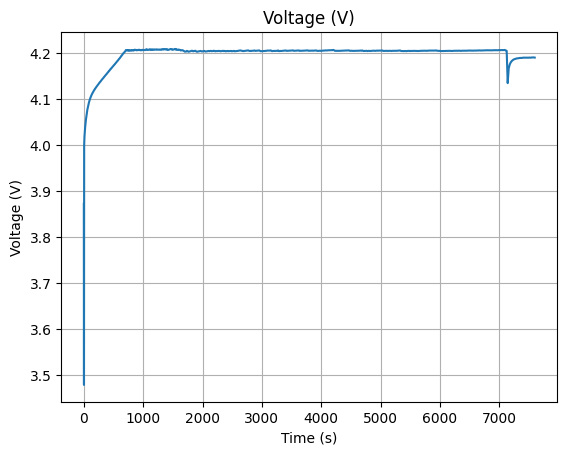

In [ ]:
import matplotlib.pyplot as plt
plt.plot(df_charge["Time"],df_charge["Voltage"])
plt.xlabel("Time (s)")
plt.ylabel("Voltage (V)")
plt.title("Voltage during Charge")
plt.grid(True)
plt.show()

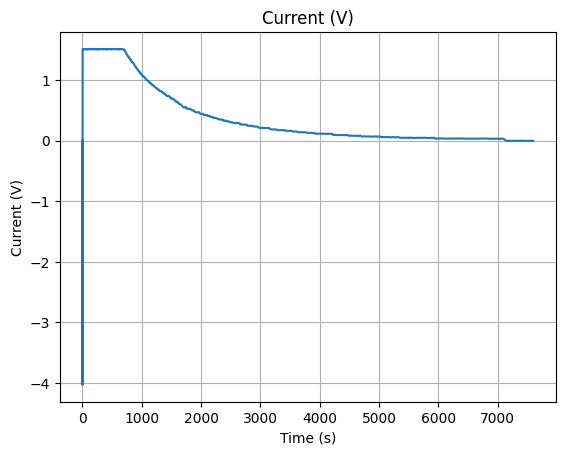

In [ ]:
plt.plot(df_charge["Time"],df_charge["Current"])
plt.xlabel("Time (s)")
plt.ylabel("Current (A)")
plt.title("Current during Charge")
plt.grid(True)
plt.show()

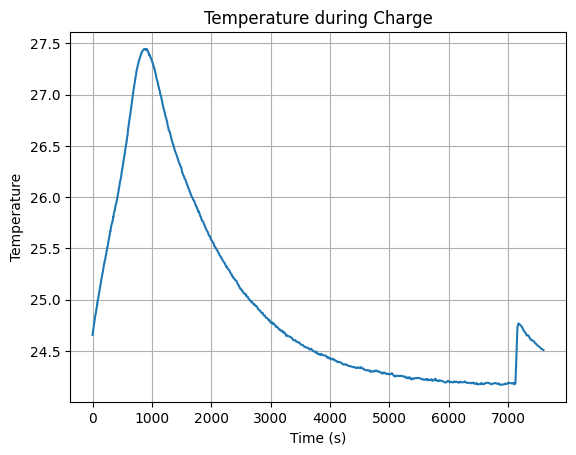

In [36]:
plt.plot(df_charge["Time"],df_charge["Temperature"])
plt.xlabel("Time (s)")
plt.ylabel("Temperature")
plt.title("Temperature during Charge")
plt.grid(True)
plt.show()

# Charge EDA

# Voltage Analysis
- 초기 충전 과정에서 전압은 약 3.5V에서 4.2V까지 빠르게 상승하였다.
- 이후 약 4.2V를 일정하게 유지하는 모습을 보였다.
- 이 모습은 리튬이온 배터리의 정전압 충전구간의 모습과 일치한다.

# Current Analysis
- 초기에는 약 1.5A의 일정한 전류가 공급되었다.
- 전압이 약 4.2V에 도달한 이후 충전 전류는 점차 감소하였다.
- 이 모습은 리튬이온 배터리에서 사용되는 CC-CV(Constant Current - Constant Voltage) 충전 방식을 보여준다.

# Temperature Analysis
- 충전 초기 전류가 크게 흐르며 온도가 상승하였다.
- 이후 충전 전류가 감소하며 발열이 줄어들어 온도도 감소하였다.

In [41]:
discharge_records = []
for record in cycle[0]:
    if record["type"][0] == "discharge":
        discharge_records.append(record)

In [42]:
first_discharge = discharge_records[0]
first_discharge.dtype

dtype([('type', 'O'), ('ambient_temperature', 'O'), ('time', 'O'), ('data', 'O')])

In [43]:
first_discharge["data"].dtype

dtype([('Voltage_measured', 'O'), ('Current_measured', 'O'), ('Temperature_measured', 'O'), ('Current_load', 'O'), ('Voltage_load', 'O'), ('Time', 'O'), ('Capacity', 'O')])

In [ ]:
#첫 사이클 Capacity
first_discharge["data"][0,0]["Capacity"]

array([[1.85648742]])

In [45]:
len(discharge_records)

168

In [ ]:
# Capacity 모으기 
capacities = []
for record in discharge_records:
    capacity = record["data"][0,0]["Capacity"][0,0]
    capacities.append(capacity)

In [50]:
df_discharge = pd.DataFrame({
    "Cycle": range(1, len(capacities)+1),
    "Capacity": capacities
})

In [51]:
df_discharge.head()

,Cycle,Capacity
0,1,1.856487
1,2,1.846327
2,3,1.835349
3,4,1.835263
4,5,1.834646


In [53]:
# iloc[0]은 무조건 첫 번째 위치를 의미
initial_capacity = df_discharge["Capacity"].iloc[0]

df_discharge["SOH"] = (
    df_discharge["Capacity"] / initial_capacity * 100
)
df_discharge.head()

,Cycle,Capacity,SOH
0,1,1.856487,100.000000
1,2,1.846327,99.452721
2,3,1.835349,98.861386
3,4,1.835263,98.856718
4,5,1.834646,98.823482


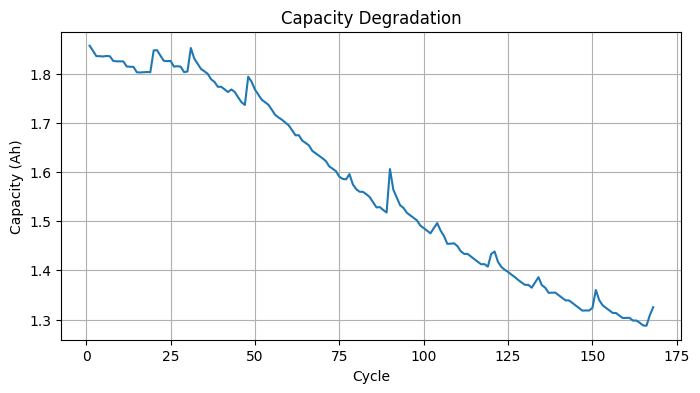

In [54]:
plt.figure(figsize=(8,4))
plt.plot(df_discharge["Cycle"], df_discharge["Capacity"])
plt.xlabel("Cycle")
plt.ylabel("Capacity (Ah)")
plt.title("Capacity Degradation")
plt.grid(True)
plt.show()

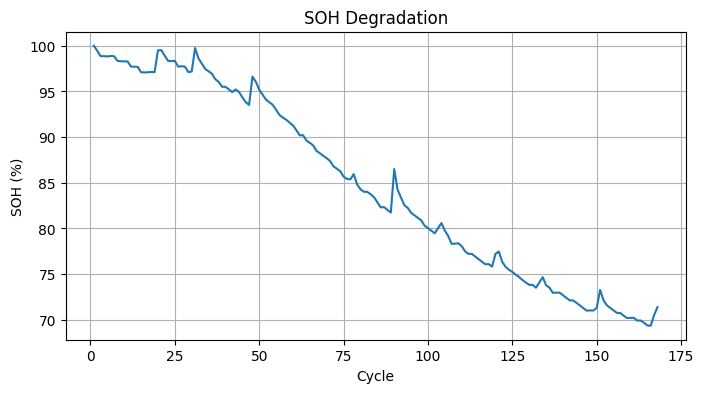

In [55]:
plt.figure(figsize=(8,4))
plt.plot(df_discharge["Cycle"], df_discharge["SOH"])
plt.xlabel("Cycle")
plt.ylabel("SOH (%)")
plt.title("SOH Degradation")
plt.grid(True)
plt.show()

### Capacity Analysis

- Discharge Cycle이 증가할수록 Capacity는 감소하였다.
- 반복적인 충/방전으로 인해 배터리의 열화가 진행되었음을 뜻한다.
- 감소율을 보면 초기에는 완만하게 감소하다가 후반부에는 감소 속도가 증가하는 경향을 보였다.

### SOH Analysis
- SOH는 초기 Capacity를 기준으로 계산하였다.
- Cycle이 증가할수록 SOH가 점진적으로 감소하였다.
- 이는 배터리 성능이 사용 횟수에 따라 저하되는 일반적인 특성과 일치한다.